In [1]:
# ==========================================================
# CONECTAR GOOGLE DRIVE
# ==========================================================

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ==========================================================
# IMPORTACION DE LIBRERIAS
# ==========================================================

# Numpy se utiliza para realizar operaciones matemáticas
# eficientes sobre arreglos y matrices.
import numpy as np

# Pandas se utiliza para cargar y manipular el dataset.
import pandas as pd

# Matplotlib se utiliza para generar gráficos.
import matplotlib.pyplot as plt

# Permite dividir el dataset en entrenamiento y prueba.
from sklearn.model_selection import train_test_split

# Permite normalizar los datos.
from sklearn.preprocessing import StandardScaler

# Permite convertir variables categóricas en numéricas
from sklearn.preprocessing import LabelEncoder

In [5]:
# ==========================================================
# CARGA DEL DATASET
# ==========================================================

# Se carga el dataset Diabetic_data desde Google Drive.
# Este dataset contiene Registros clínicos de 10 años sobre 100,000 pacientes diabéticos para predecir reingresos hospitalarios mediante 50 variables médicas y demográficas.
# Cumpliendo con los requisitos del ejercicio.

data = pd.read_csv(
    "/content/drive/MyDrive/ia/diabetic_data.csv",
    header=None
)

print("Dimensiones del dataset:")
print(data.shape)

data.head()

Dimensiones del dataset:
(101767, 50)


/tmp/ipykernel_415/3916015575.py:9: DtypeWarning: Columns (0,1,6,7,8,9,12,13,14,15,16,17,21) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(


,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
1,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
2,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
3,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
4,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO


In [6]:
# ==========================================================
# ANALISIS DEL DATASET
# ==========================================================

# Se observa información general del dataset
print(data.info())

# Se muestran estadísticas básicas
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101767 entries, 0 to 101766
Data columns (total 50 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   0       101767 non-null  object
 1   1       101767 non-null  object
 2   2       101767 non-null  object
 3   3       101767 non-null  object
 4   4       101767 non-null  object
 5   5       101767 non-null  object
 6   6       101767 non-null  object
 7   7       101767 non-null  object
 8   8       101767 non-null  object
 9   9       101767 non-null  object
 10  10      101767 non-null  object
 11  11      101767 non-null  object
 12  12      101767 non-null  object
 13  13      101767 non-null  object
 14  14      101767 non-null  object
 15  15      101767 non-null  object
 16  16      101767 non-null  object
 17  17      101767 non-null  object
 18  18      101767 non-null  object
 19  19      101767 non-null  object
 20  20      101767 non-null  object
 21  21      101767 non-null  object
 

In [14]:
# ==========================================================
# SEPARACION MANUAL POR COLUMNAS ESPECIFICAS (Puro número)
# ==========================================================

# Seleccionamos solo columnas que sabemos que tienen números
# 9: time_in_hospital
# 12 a 17: num_lab, num_proc, num_med, outpatient, emergency, inpatient
X = data.iloc[1:, [9, 12, 13, 14, 15, 16, 17]].values

# Variable objetivo (y) - La última de todas
y = (data.iloc[1:, 49] == '<30').astype(int).values

print("Variables de entrada (X):", X.shape)
print("Variable objetivo (y):", y.shape)

Variables de entrada (X): (101766, 7)
Variable objetivo (y): (101766,)


In [15]:
# ==========================================================
# NORMALIZACION DE DATOS
# ==========================================================
# scaler va a transformar tus números (como 41 o 1) a una
# escala pequeña (media 0, desviación 1) para que el modelo no explote.

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
print("Datos normalizados (primeras 2 filas):")
print(X_scaled[:2])

Datos normalizados (primeras 2 filas):
[[-1.13764856 -0.10651686 -0.78539774 -1.84826769 -0.29146149 -0.21262018
  -0.50327619]
 [-0.46765271  0.80838387 -0.78539774  0.24338965 -0.29146149 -0.21262018
  -0.50327619]]


In [27]:
# ==========================================================
# DIVISION DE DATOS
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Datos entrenamiento (X):", X_train.shape)
print("Datos prueba (X):", X_test.shape)
print("Etiquetas entrenamiento (y):", y_train.shape)

Datos entrenamiento (X): (81412, 7)
Datos prueba (X): (20354, 7)
Etiquetas entrenamiento (y): (81412,)


In [28]:
# ==========================================================
# FUNCION SIGMOIDE
# ==========================================================

def sigmoid(z):

    return 1 / (1 + np.exp(-z))

In [29]:
# ==========================================================
# FUNCION DE COSTO
# ==========================================================

def cost_function(X, y, theta):

    m = len(y)

    h = sigmoid(np.dot(X, theta))

    cost = (-1/m) * np.sum(
        y*np.log(h) + (1-y)*np.log(1-h)
    )

    return cost

In [30]:
# ==========================================================
# GRADIENTE DESCENDENTE
# ==========================================================

def gradient_descent(X, y, theta, alpha, iterations):

    m = len(y)

    cost_history = []

    for i in range(iterations):

        h = sigmoid(np.dot(X,theta))

        gradient = (1/m) * np.dot(X.T,(h-y))

        theta = theta - alpha * gradient

        cost = cost_function(X,y,theta)

        cost_history.append(cost)

    return theta, cost_history

In [31]:
# ==========================================================
# ENTRENAMIENTO DEL MODELO
# ==========================================================

# agregar columna de 1 para intercepto
X_train = np.c_[np.ones(X_train.shape[0]), X_train]
X_test = np.c_[np.ones(X_test.shape[0]), X_test]
theta = np.zeros(X_train.shape[1])

theta, cost_history = gradient_descent(
    X_train,
    y_train,
    theta,
    0.01,
    10000
)

print("Theta final:")
print(theta)

Theta final:
[-2.13749577e+00  8.43951346e-02  7.49128250e-03 -5.13912872e-02
  7.21427168e-02  1.44237802e-03  3.68749566e-02  3.39958425e-01]


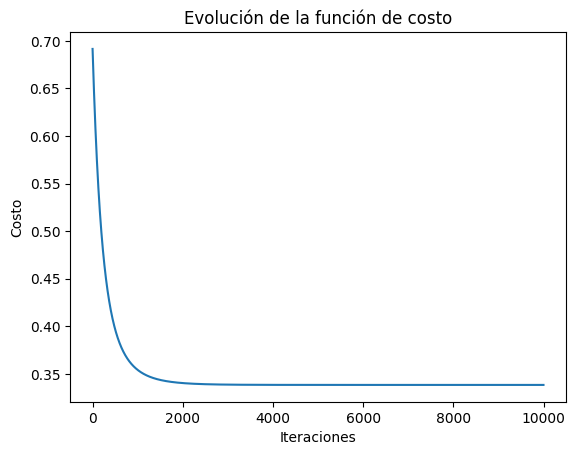

In [32]:
# ==========================================================
# GRAFICA DE COSTO
# ==========================================================

plt.plot(cost_history)

plt.title("Evolución de la función de costo")

plt.xlabel("Iteraciones")

plt.ylabel("Costo")

plt.show()

In [33]:
# ==========================================================
# PREDICCIONES
# ==========================================================

def predict(X,theta):

    prob = sigmoid(np.dot(X,theta))

    return prob >= 0.5

In [34]:
# ==========================================================
# EVALUACION DEL MODELO
# ==========================================================

pred = predict(X_test,theta)

accuracy = np.mean(pred == y_test)

print(f"Precisión del modelo: {accuracy * 100:.2f} %")

Precisión del modelo: 88.73 %
